# Phase 5 — CNN Training (ResNet18 Transfer Learning)

Two-stage training protocol:
- **Stage 1** — backbone frozen, head trained only (10 epochs max, fast)
- **Stage 2** — full fine-tuning, differential LR (30 epochs max, early stopping)

Hardware: RTX 4050 (6 GB VRAM) | Mixed precision enabled | Batch size 16

Datasets used: ACRIMA + RIMONE + AIROGS (classification splits)


In [1]:
import sys
from pathlib import Path

def _find_project_root(start, marker='config.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\Machine Learning\glaucoma detection project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

from sklearn.metrics import ConfusionMatrixDisplay

from config import (
    DEVICE, BATCH_SIZE, FIGURES_DIR, RESULTS_DIR, MODELS_DIR, SEED
)
from data.dataset_loader import load_all_datasets
from data.preprocessing  import build_dataloaders
from models.cnn_model    import build_model, get_optimizer, get_loss_fn
from models.trainer      import Trainer, evaluate_cnn

torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.dpi'] = 120
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM   : 6.0 GB


## 5.1 Load datasets and build DataLoaders

In [3]:
df = load_all_datasets(include=['ACRIMA', 'RIMONE', 'AIROGS'], airogs_max_samples=2000)

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

loaders = build_dataloaders(
    train_df, val_df, test_df,
    batch_size=BATCH_SIZE,
    num_workers=4,
)
train_loader = loaders['train']
val_loader   = loaders['val']
test_loader  = loaders['test']

[ACRIMA]  Total:   705  |  Glaucoma:  396  |  Normal:  309
[RIMONE]  Total:   485  |  Glaucoma:  172  |  Normal:  313
[AIROGS]  Total:  3540  |  Glaucoma: 1770  |  Normal: 1770

────────────────────────────────────────────────────
  COMBINED  Total   : 4730
            Glaucoma: 2338
            Normal  : 2392
────────────────────────────────────────────────────
Train: 2749  Val: 931  Test: 1050
[DataLoader] train: 2749 images, 172 batches
[DataLoader] val: 931 images, 59 batches
[DataLoader] test: 1050 images, 66 batches


## 5.2 Build model

In [4]:
model = build_model(
    num_classes=2,
    dropout=0.5,
    pretrained=True,
    freeze_backbone=True,   # Stage 1: head only
)

Backbone frozen — training head only.
Model     : GlaucomaResNet18
Device    : cuda
Params    : 11,177,538 total  |  1,026 trainable


## 5.3 Stage 1 — Train head only (backbone frozen)
Fast convergence. Head learns glaucoma-specific decision boundary from ImageNet features.

In [5]:
optimizer_s1, scheduler_s1 = get_optimizer(model, stage=1)
loss_fn = get_loss_fn(train_df['label'].values)

trainer = Trainer(
    model, optimizer_s1, scheduler_s1, loss_fn,
    run_name='glaucoma_resnet18',
)

history_s1 = trainer.fit(
    train_loader, val_loader,
    epochs=10,
    stage=1,
    patience=5,
)

Class weights — Normal: 0.998  Glaucoma: 1.002
Checkpoint → D:\Machine Learning\glaucoma detection project\outputs\models\glaucoma_resnet18_best.pth
TensorBoard → D:\Machine Learning\glaucoma detection project\outputs\logs\glaucoma_resnet18

════════════════════════════════════════════════════════════
  Stage 1 training  |  max 10 epochs  |  patience 5
════════════════════════════════════════════════════════════
  Epoch   1/10 | Train loss 0.7214  AUC 0.6303 | Val loss 0.5642  AUC 0.8193 | LR 0.000976 | 119.2s
  ✓ Best model saved  (val AUC 0.8193)
  Epoch   2/10 | Train loss 0.6558  AUC 0.7134 | Val loss 0.6062  AUC 0.8101 | LR 0.000905 | 32.6s
  Epoch   3/10 | Train loss 0.6542  AUC 0.7141 | Val loss 0.5650  AUC 0.8399 | LR 0.000796 | 34.7s
  ✓ Best model saved  (val AUC 0.8399)
  Epoch   4/10 | Train loss 0.6460  AUC 0.7234 | Val loss 0.6112  AUC 0.8404 | LR 0.000658 | 35.0s
  ✓ Best model saved  (val AUC 0.8404)
  Epoch   5/10 | Train loss 0.6354  AUC 0.7391 | Val loss 0.5406  AUC 

## 5.4 Stage 2 — Full fine-tuning
Backbone unfrozen. Lower LR applied to backbone layers to avoid catastrophic forgetting.

In [6]:
history_s2 = trainer.unfreeze_and_finetune(
    train_loader, val_loader,
    epochs=30,
    patience=7,
)


Loaded Stage 1 checkpoint (epoch 5, val AUC 0.8482)
Backbone unfrozen — full fine-tuning.
Stage 2 starts. Current best val AUC: 0.8482

════════════════════════════════════════════════════════════
  Stage 2 training  |  max 30 epochs  |  patience 7
════════════════════════════════════════════════════════════
  Epoch   1/30 | Train loss 0.5984  AUC 0.8131 | Val loss 0.5199  AUC 0.9089 | LR 0.000099 | 35.8s
  ✓ Best model saved  (val AUC 0.9089)
  Epoch   2/30 | Train loss 0.4872  AUC 0.9002 | Val loss 0.4316  AUC 0.9413 | LR 0.000098 | 37.2s
  ✓ Best model saved  (val AUC 0.9413)
  Epoch   3/30 | Train loss 0.4433  AUC 0.9243 | Val loss 0.4149  AUC 0.9441 | LR 0.000095 | 36.9s
  ✓ Best model saved  (val AUC 0.9441)
  Epoch   4/30 | Train loss 0.4271  AUC 0.9326 | Val loss 0.4070  AUC 0.9639 | LR 0.000091 | 41.0s
  ✓ Best model saved  (val AUC 0.9639)
  Epoch   5/30 | Train loss 0.3975  AUC 0.9486 | Val loss 0.3830  AUC 0.9557 | LR 0.000086 | 40.5s
  Epoch   6/30 | Train loss 0.3827  AU

## 5.5 Training curves

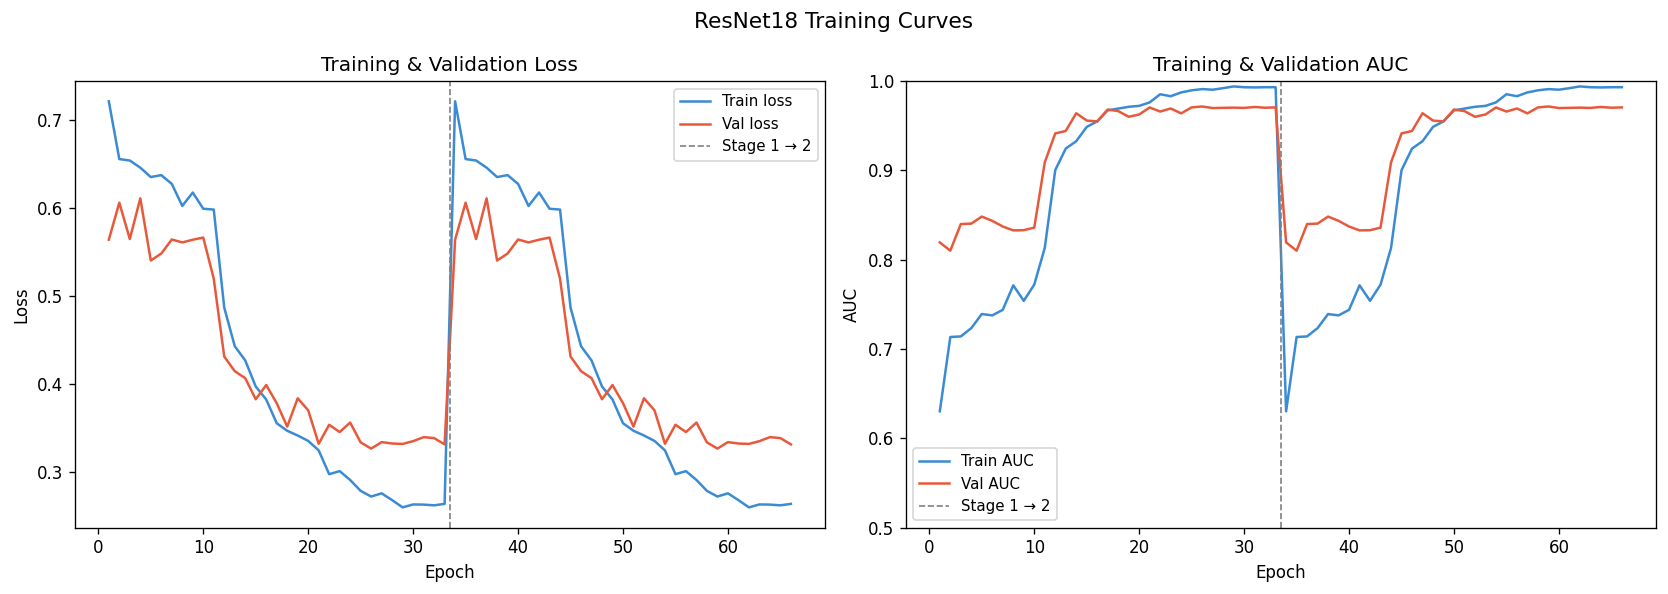

In [7]:
# Merge Stage 1 and Stage 2 history for a continuous curve
full_history = {}
s1_len = len(history_s1['train_loss'])
for key in history_s1:
    full_history[key] = history_s1[key] + history_s2.get(key, [])

epochs_range = range(1, len(full_history['train_loss']) + 1)
s1_end       = s1_len + 0.5   # vertical line between stages

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, full_history['train_loss'], '#3B8BD4', label='Train loss')
ax1.plot(epochs_range, full_history['val_loss'],   '#E8593C', label='Val loss')
ax1.axvline(s1_end, color='gray', linestyle='--', linewidth=1, label='Stage 1 → 2')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend(fontsize=9)

# AUC
ax2.plot(epochs_range, full_history['train_auc'], '#3B8BD4', label='Train AUC')
ax2.plot(epochs_range, full_history['val_auc'],   '#E8593C', label='Val AUC')
ax2.axvline(s1_end, color='gray', linestyle='--', linewidth=1, label='Stage 1 → 2')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Training & Validation AUC')
ax2.legend(fontsize=9)
ax2.set_ylim([0.5, 1.0])

plt.suptitle('ResNet18 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_training_curves.png', bbox_inches='tight')
plt.show()

## 5.6 Load best checkpoint and evaluate on test set

In [8]:
model = trainer.load_best()
cnn_metrics = evaluate_cnn(model, test_loader)

print('\n── CNN Test Set Results ──')
for k, v in cnn_metrics.items():
    if k not in ['y_true', 'y_pred', 'y_prob', 'fpr', 'tpr']:
        print(f'  {k:<14}: {v:.4f}')

Loaded best model: epoch 16, val AUC 0.9715

── CNN Test Set Results ──
  auc           : 0.9445
  sensitivity   : 0.9320
  specificity   : 0.8164
  f1            : 0.8735
  accuracy      : 0.8714
  tp            : 466.0000
  fp            : 101.0000
  tn            : 449.0000
  fn            : 34.0000


## 5.7 CNN vs Classical ML — comparison

In [9]:
classical_df = pd.read_csv(RESULTS_DIR / 'classical_ml_results.csv')

cnn_row = pd.DataFrame([{
    'model': 'CNN (ResNet18)',
    'auc':         round(cnn_metrics['auc'], 4),
    'sensitivity': round(cnn_metrics['sensitivity'], 4),
    'specificity': round(cnn_metrics['specificity'], 4),
    'f1':          round(cnn_metrics['f1'], 4),
    'accuracy':    round(cnn_metrics['accuracy'], 4),
}])

comparison = pd.concat([
    classical_df[['model','auc','sensitivity','specificity','f1','accuracy']],
    cnn_row
], ignore_index=True)

print(comparison.to_string(index=False))
comparison.to_csv(RESULTS_DIR / 'all_models_comparison.csv', index=False)

             model    auc  sensitivity  specificity     f1  accuracy
LogisticRegression 0.7126        0.670       0.6491 0.6518    0.6590
           SVM_RBF 0.7888        0.756       0.6818 0.7179    0.7171
      RandomForest 0.7674        0.714       0.6891 0.6946    0.7010
    CNN (ResNet18) 0.9445        0.932       0.8164 0.8735    0.8714


## 5.8 ROC curve — CNN vs classical ML

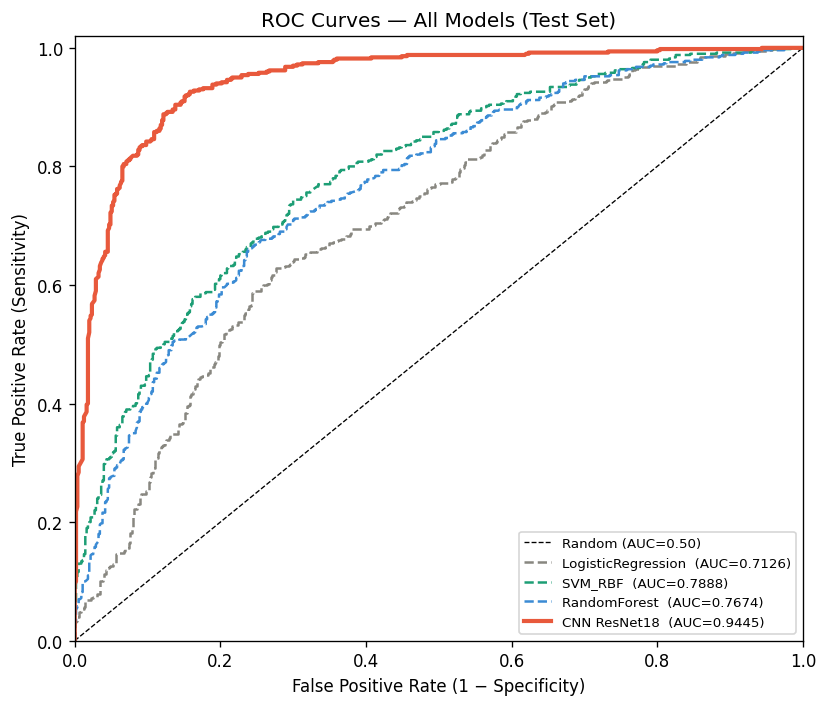

In [10]:
roc_data = joblib.load(RESULTS_DIR / 'classical_ml_roc_data.pkl')

colours = {
    'LogisticRegression': '#888780',
    'SVM_RBF':            '#1D9E75',
    'RandomForest':       '#3B8BD4',
    'CNN (ResNet18)':     '#E8593C',
}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')

for name, data in roc_data.items():
    ax.plot(data['fpr'], data['tpr'],
            color=colours.get(name, 'gray'), linewidth=1.5, linestyle='--',
            label=f"{name}  (AUC={data['auc']:.4f})")

# CNN — thicker, solid
ax.plot(cnn_metrics['fpr'], cnn_metrics['tpr'],
        color=colours['CNN (ResNet18)'], linewidth=2.5,
        label=f"CNN ResNet18  (AUC={cnn_metrics['auc']:.4f})")

ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — All Models (Test Set)')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'all_models_roc_curves.png', bbox_inches='tight')
plt.show()

## 5.9 Confusion matrix — CNN

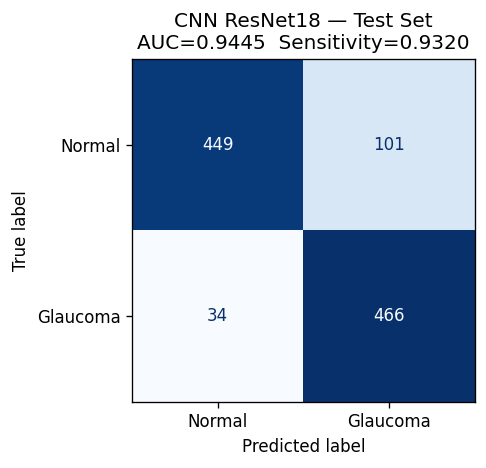

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    cnn_metrics['y_true'],
    cnn_metrics['y_pred'],
    display_labels=['Normal', 'Glaucoma'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title(f"CNN ResNet18 — Test Set\nAUC={cnn_metrics['auc']:.4f}  Sensitivity={cnn_metrics['sensitivity']:.4f}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 5.10 Save CNN results

In [12]:
cnn_save = {
    k: v for k, v in cnn_metrics.items()
    if k not in ['y_true', 'y_pred', 'y_prob', 'fpr', 'tpr']
}
cnn_save['fpr'] = cnn_metrics['fpr'].tolist()
cnn_save['tpr'] = cnn_metrics['tpr'].tolist()
cnn_save['y_true'] = cnn_metrics['y_true'].tolist()
cnn_save['y_pred'] = cnn_metrics['y_pred'].tolist()
cnn_save['y_prob'] = cnn_metrics['y_prob'].tolist()

joblib.dump(cnn_save, RESULTS_DIR / 'cnn_test_results.pkl')
print(f'CNN results saved → {RESULTS_DIR / "cnn_test_results.pkl"}')
print(f'All models comparison → {RESULTS_DIR / "all_models_comparison.csv"}')

CNN results saved → D:\Machine Learning\glaucoma detection project\outputs\results\cnn_test_results.pkl
All models comparison → D:\Machine Learning\glaucoma detection project\outputs\results\all_models_comparison.csv


---
## ✅ Phase 5 complete

Verify before moving on:
- `glaucoma_resnet18_best.pth` saved in `outputs/models/`
- CNN test AUC should exceed best classical ML AUC (0.789)
- `all_models_roc_curves.png` shows CNN curve above classical baselines
- `all_models_comparison.csv` ready for paper's results table

**Next → `05_explainability.ipynb`**  
Grad-CAM heatmaps — visualise which retinal regions the CNN focuses on for glaucoma detection.